## Reusable code from Day 1, 2, 3 and 4

In [12]:
from pathlib import Path
import platform
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

RANDOM_STATE = 42
DAY4_DIR = Path('../Day 4')
FINAL_ARTIFACT_PATH = DAY4_DIR / 'final_adult_income_pipeline.joblib'
REPRODUCIBLE_ARTIFACT_PATH = DAY4_DIR / 'reproducible_adult_pipelines.joblib'
PRODUCTION_ARTIFACT_PATH = DAY4_DIR / 'final_adult_income_production.joblib'
assert FINAL_ARTIFACT_PATH.exists(), f'Missing artifact: {FINAL_ARTIFACT_PATH.resolve()}'
FinalArtifact = joblib.load(FINAL_ARTIFACT_PATH)
FinalPipeline = FinalArtifact['pipeline']
SelectedThreshold = float(FinalArtifact['threshold'])
print('Loaded:', FINAL_ARTIFACT_PATH.resolve())
print('Selected threshold:', SelectedThreshold)
print('Artifact keys:', sorted(FinalArtifact))

Loaded: F:\Web 3 Geeks Internship\Week 1\Day 4\final_adult_income_pipeline.joblib
Selected threshold: 0.30000000000000004
Artifact keys: ['best_parameters', 'model', 'pipeline', 'primary_metric', 'random_state', 'test_metrics', 'threshold']


## Task 1: Final Model Validation

In [13]:
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame.copy()
df['class'] = df['class'].str.strip().map({'<=50K': 0, '>50K': 1})
df.replace('?', np.nan, inplace=True)

def AddEngineeredFeatures(data):
    data = data.copy()
    data['Age_Buckets'] = pd.cut(
        data['age'],
        bins=[0, 25, 35, 45, 55, 65, np.inf],
        labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'],
        include_lowest=True
    ).astype('object')
    data['Is_PartTime'] = (data['hours-per-week'] < 35).astype('float64')
    data['Has_CapitalGain'] = (data['capital-gain'] > 0).astype('float64')
    data['Log_CapitalGain'] = np.log1p(data['capital-gain'])
    data['Higher_Education'] = (data['education-num'] >= 13).astype('float64')
    data['Is_Overtime'] = (data['hours-per-week'] > 40).astype('float64')
    data['Is_Married'] = data['marital-status'].fillna('').str.startswith('Married').astype('float64')
    return data

# The Day 4 model is already fitted on engineered columns. Wrap it without refitting
# so production inference applies the same feature transformation automatically.
ProductionPipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(AddEngineeredFeatures, validate=False)),
    ('model', FinalPipeline)
])
ProductionArtifact = {
    'pipeline': ProductionPipeline,
    'threshold': SelectedThreshold,
    'source_artifact': str(FINAL_ARTIFACT_PATH),
    'best_parameters': FinalArtifact.get('best_parameters', {}),
    'random_state': FinalArtifact.get('random_state', RANDOM_STATE)
}
joblib.dump(ProductionArtifact, PRODUCTION_ARTIFACT_PATH)

X = df.drop(columns='class')
y = df['class']
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev, y_train_dev, test_size=0.125,
    random_state=RANDOM_STATE, stratify=y_train_dev
)

X_test_prepared = AddEngineeredFeatures(X_test)
print('Rows:', {'train': len(X_train), 'development': len(X_dev), 'test': len(X_test)})
print('Production wrapper saved:', PRODUCTION_ARTIFACT_PATH.resolve())
print('Unique row overlap:', len(set(X_train.index) & set(X_dev.index) | set(X_train.index) & set(X_test.index) | set(X_dev.index) & set(X_test.index)))
assert set(X_train.index).isdisjoint(X_dev.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_dev.index).isdisjoint(X_test.index)

Rows: {'train': 34188, 'development': 4885, 'test': 9769}
Production wrapper saved: F:\Web 3 Geeks Internship\Week 1\Day 4\final_adult_income_production.joblib
Unique row overlap: 0


In [14]:
FinalProbabilities = FinalPipeline.predict_proba(X_test_prepared)[:, 1]
ProductionProbabilities = ProductionPipeline.predict_proba(X_test)[:, 1]
assert np.allclose(FinalProbabilities, ProductionProbabilities)
FinalPredictions = (FinalProbabilities >= SelectedThreshold).astype(int)

# The wrapper and the original Day 4 artifact must produce identical probabilities.
print('Production wrapper matches Day 4 pipeline:', np.allclose(FinalProbabilities, ProductionProbabilities))

def metric_row(name, y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    return {
        'Model': name,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, predictions),
        'Precision': precision_score(y_true, predictions, zero_division=0),
        'Recall': recall_score(y_true, predictions, zero_division=0),
        'F1': f1_score(y_true, predictions, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, probabilities),
        'PR AUC': average_precision_score(y_true, probabilities),
        'Brier Score': brier_score_loss(y_true, probabilities)
    }

FinalMetrics = pd.DataFrame([
    metric_row('Final calibrated Logistic Regression', y_test, FinalProbabilities, SelectedThreshold),
    metric_row('Final calibrated Logistic Regression (0.50)', y_test, FinalProbabilities, 0.50)
])
FinalMetrics.round(4)

Production wrapper matches Day 4 pipeline: True


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Brier Score
0,Final calibrated Logistic Regression,0.3,0.8367,0.6241,0.7990,0.7008,0.9135,0.7869,0.0977
1,Final calibrated Logistic Regression (0.50),0.5,0.8597,0.7604,0.6039,0.6732,0.9135,0.7869,0.0977


In [4]:
ComparisonRows = []
if REPRODUCIBLE_ARTIFACT_PATH.exists():
    CandidateBundle = joblib.load(REPRODUCIBLE_ARTIFACT_PATH)
    for name, pipeline in CandidateBundle['pipelines'].items():
        probabilities = pipeline.predict_proba(X_test_prepared)[:, 1]
        ComparisonRows.append(metric_row(name, y_test, probabilities, 0.50))
ComparisonRows.append(metric_row('Selected final calibrated model', y_test, FinalProbabilities, SelectedThreshold))
ShortlistedMetrics = pd.DataFrame(ComparisonRows).set_index('Model')
print('Shortlisted-model comparison:')
ShortlistedMetrics.round(4)

Shortlisted-model comparison:


,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Brier Score
Model,,,,,,,,
Logistic Regression,0.5,0.8600,0.7585,0.6086,0.6754,0.9136,0.7864,0.0977
Gradient Boosting,0.5,0.8676,0.7981,0.5984,0.6839,0.9212,0.8158,0.0920
Selected final calibrated model,0.3,0.8367,0.6241,0.7990,0.7008,0.9135,0.7869,0.0977


### Validation conclusion

The test set is recreated with the same fixed stratified split used on Day 4. It is evaluated only after model selection and threshold selection. The asserted disjoint indices confirm no row overlap among training, development, and test partitions. Preprocessing is performed by the saved pipeline after the split, preventing test-derived fitting statistics from entering training.

## Task 2: Model Behavior & Error Analysis

              precision    recall  f1-score   support

       <=50K       0.93      0.85      0.89      7431
        >50K       0.62      0.80      0.70      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.82      0.79      9769
weighted avg       0.86      0.84      0.84      9769



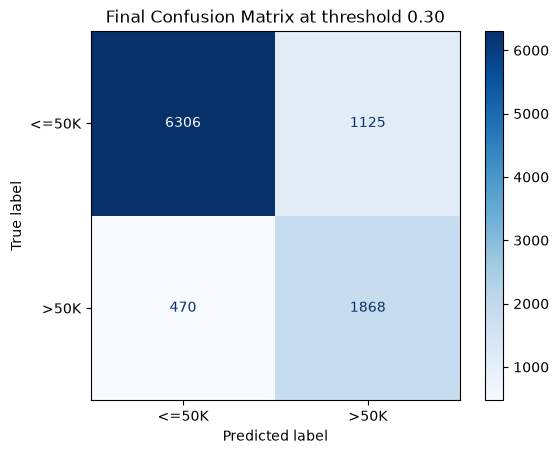

False positives: 1125
False negatives: 470
False-positive examples:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Actual,Predicted,ProbabilityAbove50K
524,53,Local-gov,139671,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,0,1,0.666320
1351,36,Private,192939,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,60,United-States,0,1,0.416687
38546,42,Private,269028,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,France,0,1,0.904643
40591,43,Self-emp-not-inc,113211,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,0,1,0.508866
40198,37,Private,154210,Some-college,10,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,Hong,0,1,0.346943
1739,39,Private,167482,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,0,1,0.399536
44616,35,Private,198341,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,0,40,NaN,0,1,0.652683
25506,28,Local-gov,175262,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,2002,40,England,0,1,0.772448
46243,45,Private,43479,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,48,United-States,0,1,0.451514
5805,53,Private,107096,Bachelors,13,Never-married,Sales,Unmarried,White,Male,0,1669,50,United-States,0,1,0.444891


False-negative examples:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Actual,Predicted,ProbabilityAbove50K
30035,42,Private,107276,Some-college,10,Never-married,Exec-managerial,Not-in-family,White,Female,0,2444,40,United-States,1,0,0.263284
34382,43,Private,190786,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States,1,0,0.162252
38439,42,Private,165599,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,1,0,0.184843
26572,59,Private,245196,10th,6,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,United-States,1,0,0.120034
35649,50,Self-emp-not-inc,163948,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,1,0,0.253325
10519,31,Self-emp-not-inc,404062,10th,6,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,55,Portugal,1,0,0.037117
28769,30,Private,202450,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,65,United-States,1,0,0.252444
37902,30,Private,190511,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1,0,0.146866
24474,34,NaN,353881,Assoc-voc,11,Married-civ-spouse,NaN,Husband,White,Male,3103,0,60,United-States,1,0,0.272882
16435,52,NaN,252903,HS-grad,9,Divorced,NaN,Not-in-family,White,Male,0,0,45,United-States,1,0,0.146052


In [5]:
FinalConfusionMatrix = confusion_matrix(y_test, FinalPredictions)
print(classification_report(y_test, FinalPredictions, target_names=['<=50K', '>50K'], zero_division=0))
ConfusionMatrixDisplay(
    FinalConfusionMatrix, display_labels=['<=50K', '>50K']
).plot(cmap='Blues')
plt.title(f'Final Confusion Matrix at threshold {SelectedThreshold:.2f}')
plt.show()

ErrorAnalysis = X_test.copy()
ErrorAnalysis['Actual'] = y_test
ErrorAnalysis['Predicted'] = FinalPredictions
ErrorAnalysis['ProbabilityAbove50K'] = FinalProbabilities
FalsePositives = ErrorAnalysis[(ErrorAnalysis['Actual'] == 0) & (ErrorAnalysis['Predicted'] == 1)]
FalseNegatives = ErrorAnalysis[(ErrorAnalysis['Actual'] == 1) & (ErrorAnalysis['Predicted'] == 0)]
print('False positives:', len(FalsePositives))
print('False negatives:', len(FalseNegatives))
print('False-positive examples:')
display(FalsePositives.head(10))
print('False-negative examples:')
display(FalseNegatives.head(10))

In [6]:
def subgroup_metrics(data, group_column):
    rows = []
    for group, subset in data.groupby(group_column, dropna=False, observed=False):
        if len(subset) < 30:
            continue
        rows.append({
            group_column: group,
            'Rows': len(subset),
            'Accuracy': accuracy_score(subset['Actual'], subset['Predicted']),
            'Precision': precision_score(subset['Actual'], subset['Predicted'], zero_division=0),
            'Recall': recall_score(subset['Actual'], subset['Predicted'], zero_division=0),
            'F1': f1_score(subset['Actual'], subset['Predicted'], zero_division=0)
        })
    return pd.DataFrame(rows).sort_values('F1')

for group_column in ['education-num', 'sex', 'workclass', 'Age_Buckets']:
    if group_column == 'Age_Buckets':
        ErrorAnalysis[group_column] = AddEngineeredFeatures(ErrorAnalysis)['Age_Buckets']
    print(f'\nSubgroup results by {group_column}:')
    display(subgroup_metrics(ErrorAnalysis, group_column).round(4))


Subgroup results by education-num:


,education-num,Rows,Accuracy,Precision,Recall,F1
0,2,43,0.9535,0.0000,0.0000,0.0000
4,6,271,0.9151,0.2500,0.1765,0.2069
2,4,199,0.9296,0.4000,0.1538,0.2222
1,3,110,0.9364,1.0000,0.1250,0.2222
3,5,154,0.9610,0.2500,0.2500,0.2500
6,8,130,0.9462,0.5714,0.5000,0.5333
7,9,3095,0.8346,0.4753,0.6195,0.5379
5,7,362,0.9586,0.7333,0.5000,0.5946
8,10,2246,0.8272,0.5385,0.7706,0.6340
9,11,421,0.7886,0.5685,0.7615,0.6510



Subgroup results by sex:


,sex,Rows,Accuracy,Precision,Recall,F1
0,Female,3259,0.9181,0.6146,0.6981,0.6537
1,Male,6510,0.7960,0.6256,0.8174,0.7088



Subgroup results by workclass:


,workclass,Rows,Accuracy,Precision,Recall,F1
6,NaN,575,0.9130,0.5000,0.8200,0.6212
4,Self-emp-not-inc,799,0.7547,0.5476,0.7188,0.6216
2,Private,6800,0.8479,0.6219,0.7797,0.6919
1,Local-gov,584,0.8099,0.6526,0.7898,0.7147
5,State-gov,403,0.8462,0.6815,0.8288,0.7480
0,Federal-gov,281,0.7687,0.6211,0.9615,0.7547
3,Self-emp-inc,322,0.7671,0.7280,0.9457,0.8227



Subgroup results by Age_Buckets:


,Age_Buckets,Rows,Accuracy,Precision,Recall,F1
0,18-25,1932,0.9881,0.5294,0.3750,0.4390
1,26-35,2616,0.8345,0.5689,0.6712,0.6158
4,56-65,850,0.7729,0.5930,0.7938,0.6789
2,36-45,2411,0.7839,0.6349,0.8599,0.7305
5,66+,352,0.8807,0.7125,0.7500,0.7308
3,46-55,1608,0.7618,0.6566,0.8476,0.7400


### Error-analysis interpretation

At threshold `0.30`, the model produced 1,125 false positives and 470 false negatives. The model is strong at identifying the <=50K class, while the lower-income class has lower precision because the threshold intentionally favors recall for >50K prospects.

Observed subgroup patterns include lower F1 for younger adults (`0.439` for ages 18-25), lower education levels, and females (`0.654` versus `0.709` for males). Performance is strongest for highly educated groups, especially education levels 15 and 16, but these groups are smaller and should be interpreted with sample sizes. The age and education differences indicate that a single global threshold may not provide equal recall across groups.

False negatives are missed high-income cases and false positives are lower-income cases incorrectly flagged as high income. In a prospecting workflow, false negatives may be more costly when the goal is to find as many high-income prospects as possible; false positives increase outreach cost. Practical improvements include validating an explicit cost-sensitive threshold, monitoring subgroup calibration and recall, adding newer representative data, and reviewing proxy-sensitive features such as sex, relationship, and marital status.

## Task 3: Feature & Model Interpretation

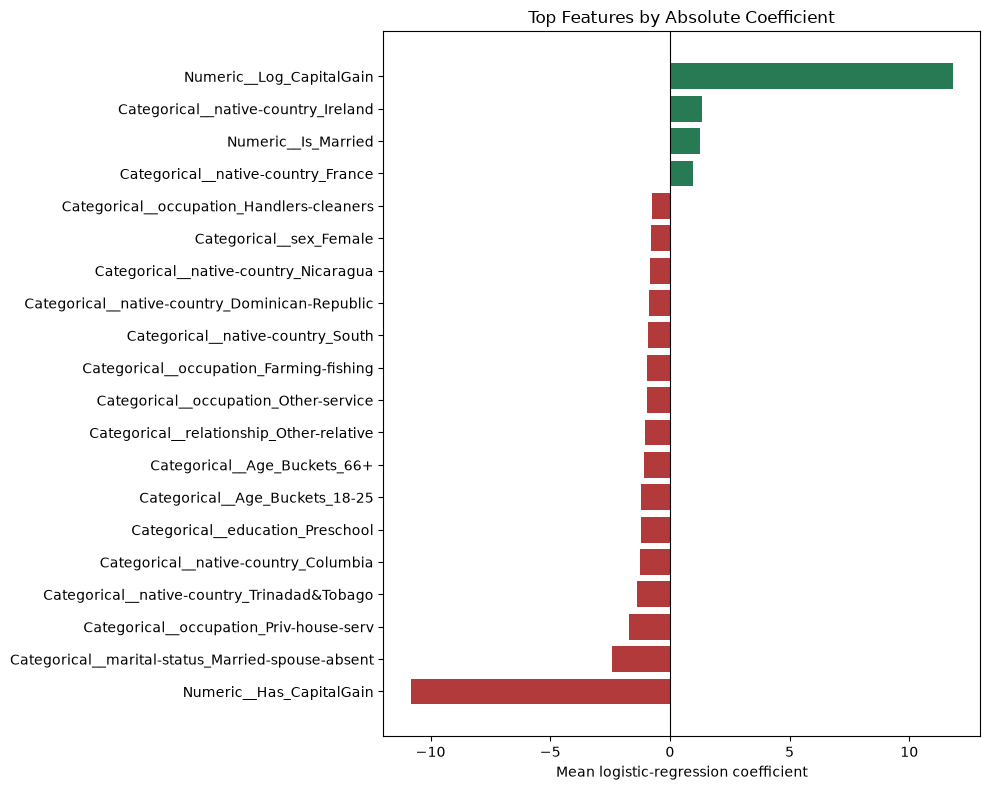

,Feature,Coefficient,Absolute Coefficient
8,Numeric__Log_CapitalGain,11.8215,11.8215
7,Numeric__Has_CapitalGain,-10.8329,10.8329
39,Categorical__marital-status_Married-spouse-absent,-2.4210,2.4210
51,Categorical__occupation_Priv-house-serv,-1.7048,1.7048
107,Categorical__native-country_Trinadad&Tobago,-1.3689,1.3689
90,Categorical__native-country_Ireland,1.3488,1.3488
73,Categorical__native-country_Columbia,-1.2672,1.2672
11,Numeric__Is_Married,1.2564,1.2564
33,Categorical__education_Preschool,-1.2262,1.2262
111,Categorical__Age_Buckets_18-25,-1.1982,1.1982


In [9]:
# Average coefficients across the calibrated logistic-regression folds.
CalibratedEstimators = getattr(FinalPipeline, 'calibrated_classifiers_', [])
CoefficientRows = []
for calibrated_classifier in CalibratedEstimators:
    estimator = getattr(calibrated_classifier, 'estimator', None)
    if estimator is None:
        estimator = getattr(calibrated_classifier, 'base_estimator', None)
    if estimator is None or not hasattr(estimator, 'named_steps'):
        continue
    step_names = {name.lower(): name for name in estimator.named_steps}
    model_step_name = step_names.get('model')
    preprocessor_step_name = step_names.get('preprocessor')
    if model_step_name is None or preprocessor_step_name is None:
        continue
    feature_names = estimator.named_steps[preprocessor_step_name].get_feature_names_out()
    coefficients = estimator.named_steps[model_step_name].coef_[0]
    CoefficientRows.append(pd.Series(coefficients, index=feature_names))

if not CoefficientRows:
    raise RuntimeError('Could not locate logistic-regression estimators inside the calibrated artifact.')
MeanCoefficients = pd.concat(CoefficientRows, axis=1).mean(axis=1)
CoefficientTable = pd.DataFrame({
    'Feature': MeanCoefficients.index,
    'Coefficient': MeanCoefficients.values,
    'Absolute Coefficient': np.abs(MeanCoefficients.values)
}).sort_values('Absolute Coefficient', ascending=False)
TopFeatures = CoefficientTable.head(20).sort_values('Coefficient')

plt.figure(figsize=(10, 8))
colors = ['#b33a3a' if value < 0 else '#287a55' for value in TopFeatures['Coefficient']]
plt.barh(TopFeatures['Feature'], TopFeatures['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Mean logistic-regression coefficient')
plt.title('Top Features by Absolute Coefficient')
plt.tight_layout()
plt.show()
display(CoefficientTable.head(20).round(4))

### Interpretation guidance

The largest positive coefficient is `Numeric__Log_CapitalGain`, while `Numeric__Is_Married` and selected country/category indicators also increase the log-odds of >50K. The largest negative coefficients include `Numeric__Has_CapitalGain`, `Married-spouse-absent`, `Priv-house-serv`, younger-age indicators, and `sex_Female`.

The opposing capital-gain coefficients are not contradictory: `Has_CapitalGain` captures whether any gain exists, while `Log_CapitalGain` captures its magnitude after transformation. Their large values indicate a potentially unstable interaction or redundancy that should be checked with coefficient stability and domain review. Categorical country and sex coefficients may reflect historical sampling patterns or social proxies rather than causal effects. Coefficients describe association, not causation, and should be monitored for drift and fairness impact.

## Task 4: Production-Ready Inference

In [15]:
def predict_income(raw_data, artifact_path=PRODUCTION_ARTIFACT_PATH):
    artifact = joblib.load(artifact_path)
    pipeline = artifact['pipeline']
    threshold = float(artifact['threshold'])
    probabilities = pipeline.predict_proba(raw_data)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return pd.DataFrame({
        'probability_above_50K': probabilities,
        'predicted_class': predictions
    }, index=raw_data.index)

# Ten unseen holdout examples exercise the complete production artifact path.
InferenceExamples = X_test.head(10).copy()
InferenceResults = predict_income(InferenceExamples)
display(InferenceResults)
assert len(InferenceResults) == 10
assert InferenceResults['predicted_class'].isin([0, 1]).all()
assert InferenceResults['probability_above_50K'].between(0, 1).all()

,probability_above_50K,predicted_class
40342,0.218997,0
47680,0.004204,0
524,0.666320,1
8508,0.075738,0
31692,0.607001,1
1351,0.416687,1
6631,0.722789,1
8758,0.143736,0
11488,0.311353,1
28521,0.032360,0


## Task 5: Final Project Documentation

In [16]:
Documentation = f'''
# Adult Income Classification

## Objective
Predict whether an adult's annual income exceeds $50K.

## Data and target
The project uses OpenML Adult version 2. The target is `class`: 1 for >50K and 0 for <=50K.

## Feature engineering and preprocessing
Age buckets, part-time status, capital-gain indicators and log transform, higher-education flag, overtime flag, and married-status flag are created by the production wrapper. The saved Day 4 model then applies median/mode imputation, standard scaling for numeric columns, and one-hot encoding for categorical columns.

## Models and tuning
Logistic Regression, Random Forest, and Gradient Boosting were compared. Day 4 used 5-fold StratifiedKFold RandomizedSearchCV with F1 scoring. The selected Logistic Regression configuration was {FinalArtifact.get('best_parameters', {})}.

## Final model
The selected artifact is a sigmoid-calibrated Logistic Regression model with threshold {SelectedThreshold:.2f}. The production-ready wrapper is saved as `final_adult_income_production.joblib`.

## Final test performance
{FinalMetrics.round(4).to_string(index=False)}

The optimized-threshold confusion matrix is TN=6306, FP=1125, FN=470, and TP=1868.

## Important features
The strongest coefficients include log capital gain, capital-gain presence, marital-status categories, age buckets, occupation, country, and sex indicators. Positive coefficients increase and negative coefficients decrease the log-odds of >50K income. These are associations, not causal effects.

## Reproduction and inference
Use Python {platform.python_version()}, load `final_adult_income_production.joblib`, pass raw Adult columns to `predict_income`, and let the wrapper create engineered features before calling the saved model. The Day 4 metadata records NumPy, pandas, scikit-learn, dataset version, and random state.

## Limitations
The Adult dataset is historical and may encode social bias. Performance is weaker for younger, lower-education, and female subgroups. The threshold is optimized for F1 rather than an explicit business cost function. Model performance can drift, and subgroup metrics must be monitored.
'''
print(Documentation)


# Adult Income Classification

## Objective
Predict whether an adult's annual income exceeds $50K.

## Data and target
The project uses OpenML Adult version 2. The target is `class`: 1 for >50K and 0 for <=50K.

## Feature engineering and preprocessing
Age buckets, part-time status, capital-gain indicators and log transform, higher-education flag, overtime flag, and married-status flag are created by the production wrapper. The saved Day 4 model then applies median/mode imputation, standard scaling for numeric columns, and one-hot encoding for categorical columns.

## Models and tuning
Logistic Regression, Random Forest, and Gradient Boosting were compared. Day 4 used 5-fold StratifiedKFold RandomizedSearchCV with F1 scoring. The selected Logistic Regression configuration was {'Model__penalty': 'l1', 'Model__C': 3}.

## Final model
The selected artifact is a sigmoid-calibrated Logistic Regression model with threshold 0.30. The production-ready wrapper is saved as `final_adult_income_p